<a href="https://colab.research.google.com/github/RahulArra/Deep-Learning-Practise/blob/main/dataset_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Installation

In [ ]:
import json

kaggle_dict = {
    "username": "rahularra",
    "key": "KGAT_466ff1540cc6ca57296e5bcfd0c94924"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_dict, f)

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
!pip install kaggle

#Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/drive/MyDrive/

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:27<00:00, 90.1MB/s]



In [ ]:
!unzip -q /content/drive/MyDrive/chest-xray-pneumonia.zip -d /content/drive/MyDrive/

In [ ]:
import os
import shutil
import random

source_dir = "/content/drive/MyDrive/chest_xray/train"
target_dir = "/content/chest_xray_subset/train"

classes = ["NORMAL", "PNEUMONIA"]

for cls in classes:
    os.makedirs(os.path.join(target_dir, cls), exist_ok=True)

    images = os.listdir(os.path.join(source_dir, cls))
    selected = random.sample(images, 1000)

    for img in selected:
        src = os.path.join(source_dir, cls, img)
        dst = os.path.join(target_dir, cls, img)
        shutil.copy(src, dst)

# preproccessing

In [ ]:
train_dir = "/content/drive/MyDrive/chest_xray/train"
test_dir = "/content/drive/MyDrive/chest_xray/test"

In [ ]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dir = "/content/drive/MyDrive/chest_xray/chest_xray/test"
test_dir = "/content/drive/MyDrive/chest_xray/chest_xray/test"

full_train_data = datasets.ImageFolder(root=train_dir, transform=transform)
full_test_data = datasets.ImageFolder(root=test_dir, transform=transform)

In [ ]:
from torch.utils.data import Subset
import random

subset_size = 2000

indices = list(range(len(full_train_data)))
random.shuffle(indices)

train_indices = indices[:subset_size]

train_data = Subset(full_train_data, train_indices)
test_indices = list(range(len(full_test_data)))
random.shuffle(test_indices)

test_data = Subset(full_test_data, test_indices[:500])

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [3]:
import os
import numpy as np
from PIL import Image

train_dir = "/content/drive/MyDrive/chest_xray/chest_xray/train"
test_dir = "/content/drive/MyDrive/chest_xray/chest_xray/test"

IMG_SIZE = 64

def load_data(data_dir, limit_per_class=None):
    X = []
    y = []

    classes = ["NORMAL", "PNEUMONIA"]
    image_extensions = ('.jpeg', '.jpg', '.png') # Common image extensions

    for label, cls in enumerate(classes):
        path = os.path.join(data_dir, cls)
        images = os.listdir(path)

        # Filter out non-image files and apply limit
        valid_images = [img for img in images if img.lower().endswith(image_extensions)]

        if limit_per_class is not None:
            selected = valid_images[:limit_per_class]
        else:
            selected = valid_images

        for img_name in selected:
            img_path = os.path.join(path, img_name)
            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((IMG_SIZE, IMG_SIZE))
                img = np.array(img) / 255.0

                X.append(img.flatten())
                y.append(label)
            except Exception as e:
                print(f"Could not process {img_path}: {e}")

    return np.array(X), np.array(y)

X_train, y_train = load_data(train_dir, limit_per_class=30000)
X_test, y_test = load_data(test_dir, limit_per_class=12000)

np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)
np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

#MLP

In [ ]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    learning_rate_init=0.001,
    max_iter=50,
    random_state=42
)

model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=50, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

for lr in [0.1, 0.01, 0.001]:
    model = MLPClassifier(
        hidden_layer_sizes=(128,64),
        learning_rate_init=lr,
        max_iter=50
    )

    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)

    print("LR:", lr, "Accuracy:", acc)

configs = [(64,), (128,64), (256,128,64)]

for cfg in configs:
    model = MLPClassifier(hidden_layer_sizes=cfg, max_iter=50)
    model.fit(X_train, y_train)

    print("Layers:", cfg, "Accuracy:", model.score(X_test, y_test))

Accuracy: 0.7808988764044944


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


LR: 0.1 Accuracy: 0.5617977528089888
LR: 0.01 Accuracy: 0.7865168539325843


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


LR: 0.001 Accuracy: 0.7453183520599251


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Layers: (64,) Accuracy: 0.7602996254681648


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Layers: (128, 64) Accuracy: 0.6853932584269663
Layers: (256, 128, 64) Accuracy: 0.6910112359550562


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


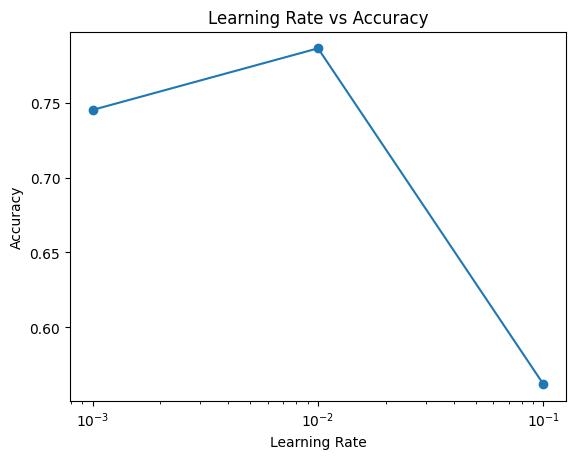

In [ ]:
import matplotlib.pyplot as plt

learning_rates = [0.1, 0.01, 0.001]
accuracies = [0.5618, 0.7865, 0.7453]

plt.figure()
plt.plot(learning_rates, accuracies, marker='o')
plt.xscale('log')

plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Learning Rate vs Accuracy")

plt.show()

The Chest X-ray dataset is complex and high-dimensional

Flattening images for MLP leads to loss of spatial information

Hence, MLP gives moderate accuracy (~75–78%)

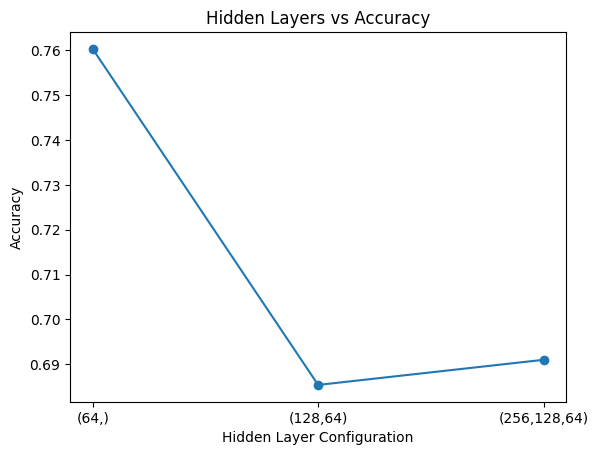

In [ ]:
layers = ["(64,)", "(128,64)", "(256,128,64)"]
accuracies_layers = [0.7603, 0.6854, 0.6910]

plt.figure()
plt.plot(layers, accuracies_layers, marker='o')

plt.xlabel("Hidden Layer Configuration")
plt.ylabel("Accuracy")
plt.title("Hidden Layers vs Accuracy")

plt.show()

(64):
Good performance (~76%)

Simpler model generalizes better
(128, 64):
Accuracy drops (~68%)

Possible overfitting or insufficient training

(256, 128, 64):
Slight improvement but still lower (~69%)

Deep MLP struggles with image data

# Gradient Descent

In [ ]:
import numpy as np

X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

def create_model():
    model = models.Sequential([
        Input(shape=(X_train.shape[1],)), # Explicitly define the input shape
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
optimizers_constructors = {
    "SGD": tf.keras.optimizers.SGD,
    "SGD_Momentum": lambda lr: tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9),
    "Nesterov": lambda lr: tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True),
    "Adagrad": tf.keras.optimizers.Adagrad,
    "RMSProp": tf.keras.optimizers.RMSprop,
    "Adadelta": tf.keras.optimizers.Adadelta,
    "Adam": tf.keras.optimizers.Adam
}

learning_rates = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
results = {}

print("Evaluating optimizers with different learning rates:")
for name, opt_constructor in optimizers_constructors.items():
    best_acc_for_optimizer = 0
    best_lr_for_optimizer = None
    print(f"\n--- Optimizer: {name} ---")
    for lr in learning_rates:
        # Construct the optimizer with the current learning rate
        if name in ["SGD_Momentum", "Nesterov"]:
            opt = opt_constructor(lr)
        else:
            opt = opt_constructor(learning_rate=lr)

        model = create_model()

        model.compile(
            optimizer=opt,
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            X_train, y_train,
            epochs=15,
            batch_size=32,
            verbose=0
        )

        loss, acc = model.evaluate(X_test, y_test, verbose=0)

        print(f"  LR: {lr}, Accuracy: {acc:.4f}")

        if acc > best_acc_for_optimizer:
            best_acc_for_optimizer = acc
            best_lr_for_optimizer = lr

    results[name] = {"best_accuracy": best_acc_for_optimizer, "best_learning_rate": best_lr_for_optimizer}
    print(f"Best for {name}: Accuracy = {best_acc_for_optimizer:.4f}, LR = {best_lr_for_optimizer}")

# Print overall best optimizer and LR
print("\n--- Overall Best Optimizer and Learning Rate ---")
overall_best_acc = 0
overall_best_optimizer = None
overall_best_lr = None

for name, res in results.items():
    if res["best_accuracy"] > overall_best_acc:
        overall_best_acc = res["best_accuracy"]
        overall_best_optimizer = name
        overall_best_lr = res["best_learning_rate"]

print(f"Overall Best: Optimizer = {overall_best_optimizer}, Accuracy = {overall_best_acc:.4f}, LR = {overall_best_lr}")

Evaluating optimizers with different learning rates:

--- Optimizer: SGD ---
  LR: 0.1, Accuracy: 0.4382
  LR: 0.05, Accuracy: 0.8109
  LR: 0.01, Accuracy: 0.7996
  LR: 0.005, Accuracy: 0.7322
  LR: 0.001, Accuracy: 0.8352
  LR: 0.0005, Accuracy: 0.8184
  LR: 0.0001, Accuracy: 0.6985
Best for SGD: Accuracy = 0.8352, LR = 0.001

--- Optimizer: SGD_Momentum ---
  LR: 0.1, Accuracy: 0.5618
  LR: 0.05, Accuracy: 0.4382
  LR: 0.01, Accuracy: 0.7116
  LR: 0.005, Accuracy: 0.6816
  LR: 0.001, Accuracy: 0.7509
  LR: 0.0005, Accuracy: 0.7640
  LR: 0.0001, Accuracy: 0.8240
Best for SGD_Momentum: Accuracy = 0.8240, LR = 0.0001

--- Optimizer: Nesterov ---
  LR: 0.1, Accuracy: 0.4382
  LR: 0.05, Accuracy: 0.5618
  LR: 0.01, Accuracy: 0.7360
  LR: 0.005, Accuracy: 0.7584
  LR: 0.001, Accuracy: 0.7772
  LR: 0.0005, Accuracy: 0.7603
  LR: 0.0001, Accuracy: 0.8258
Best for Nesterov: Accuracy = 0.8258, LR = 0.0001

--- Optimizer: Adagrad ---
  LR: 0.1, Accuracy: 0.4382
  LR: 0.05, Accuracy: 0.4382
  LR

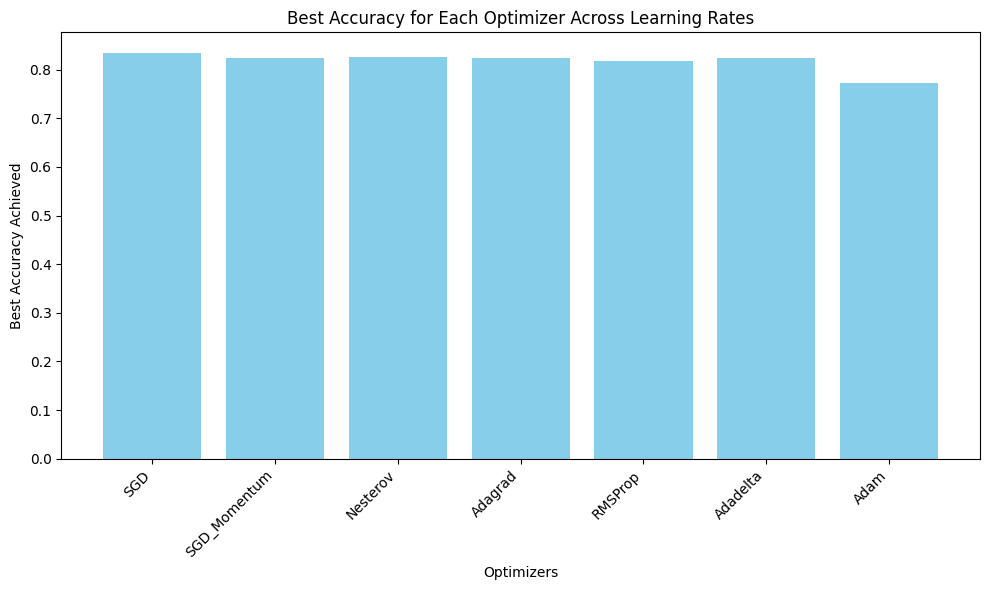

In [ ]:
import matplotlib.pyplot as plt

names = list(results.keys())
acc_values = [res['best_accuracy'] for res in results.values()]

plt.figure(figsize=(10, 6))
plt.bar(names, acc_values, color='skyblue')

plt.xlabel("Optimizers")
plt.ylabel("Best Accuracy Achieved")
plt.title("Best Accuracy for Each Optimizer Across Learning Rates")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Adam is considered as th best optimizer , it got less accuracy than others , Sgd got better than all other as our model is imple  like we only used a basic mlp , traditional approach got better results , we will check on our future work if it still good or not . It's future work for now.

# Regularization

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

loss, acc = model.evaluate(X_test, y_test)
print("Base Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8650 - loss: 0.3194 - val_accuracy: 0.7660 - val_loss: 0.5099
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9369 - loss: 0.1589 - val_accuracy: 0.7292 - val_loss: 0.7956
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9454 - loss: 0.1450 - val_accuracy: 0.7420 - val_loss: 0.7660
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9415 - loss: 0.1480 - val_accuracy: 0.6827 - val_loss: 1.3755
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9454 - loss: 0.1396 - val_accuracy: 0.7308 - val_loss: 0.9438
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9561 - loss: 0.1235 - val_accuracy: 0.6891 - val_loss: 1.4396
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9492 - loss: 0.1329 - val_accuracy: 0.7933 - val_loss: 0.6383
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9431 - loss: 0.1430 - val_accuracy: 0.

base model without any regularization tech is 0.76

l2 regularization

In [12]:
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

model = models.Sequential([
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

loss, acc = model.evaluate(X_test, y_test)
print("L2 Accuracy:", acc)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8599 - loss: 0.6346 - val_accuracy: 0.7933 - val_loss: 0.6744
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9283 - loss: 0.4489 - val_accuracy: 0.7628 - val_loss: 0.7240
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9434 - loss: 0.3750 - val_accuracy: 0.7436 - val_loss: 0.8009
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9479 - loss: 0.3380 - val_accuracy: 0.7388 - val_loss: 0.8797
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9454 - loss: 0.3189 - val_accuracy: 0.7019 - val_loss: 1.1694
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9530 - loss: 0.2926 - val_accuracy: 0.7628 - val_loss: 0.7936
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9536 - loss: 0.2775 - val_accuracy: 0.7083 - val_loss: 1.1872
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9502 - loss: 0.2707 - val_accuracy: 0

Accuracy decreased slightly (~74.51%) for 10 epoch
Indicates that:
Model was not heavily overfitting
Regularization constrained weights too much

batch sizze 63 gave less acc of 71

for 20 epochs
it's 74.8



we can see that training acc is 95 but the val acc is 74  even though we used regularization , it is bcoz of flattening it destroys the spatial structure of the image .

drop out

In [6]:
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

loss, acc = model.evaluate(X_test, y_test)
print("Dropout Accuracy:", acc)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7189 - loss: 0.5706 - val_accuracy: 0.6250 - val_loss: 0.5242
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7429 - loss: 0.3941 - val_accuracy: 0.6250 - val_loss: 0.6273
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7634 - loss: 0.3948 - val_accuracy: 0.8478 - val_loss: 0.4258
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8324 - loss: 0.3455 - val_accuracy: 0.7179 - val_loss: 0.6453
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8238 - loss: 0.3416 - val_accuracy: 0.7580 - val_loss: 0.5372
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8332 - loss: 0.3266 - val_accuracy: 0.7676 - val_loss: 0.5506
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8441 - loss: 0.3116 - val_accuracy: 0.7949 - val_loss: 0.5056
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8184 - loss: 0.3374 - val_accuracy: 0

ccuracy improved (~81.73%)
Prevents co-adaptation of neurons
Forces model to learn robust features

Insight:

Dropout effectively improves generalization as we can see training acc decreased from 95 to 85 , which tells that drop out improved trainig acc but still val acc is poor .

adding noise

In [13]:
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

model = models.Sequential([
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(X_train.shape[1],)),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

loss, acc = model.evaluate(X_test, y_test)
print("L2 Accuracy:", acc)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7508 - loss: 0.8315 - val_accuracy: 0.6603 - val_loss: 0.8184
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8340 - loss: 0.6419 - val_accuracy: 0.7340 - val_loss: 0.7304
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8767 - loss: 0.5390 - val_accuracy: 0.7308 - val_loss: 0.7446
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8993 - loss: 0.4724 - val_accuracy: 0.7708 - val_loss: 0.6656
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9132 - loss: 0.4302 - val_accuracy: 0.7356 - val_loss: 0.8310
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9176 - loss: 0.4019 - val_accuracy: 0.8157 - val_loss: 0.5878
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9254 - loss: 0.3744 - val_accuracy: 0.7612 - val_loss: 0.7337
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9294 - loss: 0.3552 - val_accuracy: 0.

adding dropout and regularization still failed

In [7]:
import numpy as np

X_train_noise = X_train + 0.1 * np.random.normal(size=X_train.shape)
X_test_noise = X_test + 0.1 * np.random.normal(size=X_test.shape)

model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_noise, y_train, epochs=10, batch_size=32, validation_data=(X_test_noise, y_test))

loss, acc = model.evaluate(X_test_noise, y_test)
print("Noise Accuracy:", acc)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8482 - loss: 0.3433 - val_accuracy: 0.7596 - val_loss: 0.4729
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9254 - loss: 0.1927 - val_accuracy: 0.7356 - val_loss: 0.6854
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9362 - loss: 0.1594 - val_accuracy: 0.7612 - val_loss: 0.6534
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9461 - loss: 0.1418 - val_accuracy: 0.6763 - val_loss: 1.4470
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9452 - loss: 0.1354 - val_accuracy: 0.7628 - val_loss: 0.7517
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9511 - loss: 0.1276 - val_accuracy: 0.7436 - val_loss: 0.8189
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9613 - loss: 0.1021 - val_accuracy: 0.7420 - val_loss: 0.9131
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9572 - loss: 0.1112 - val_accuracy: 0.

early stopping

In [8]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

loss, acc = model.evaluate(X_test, y_test)
print("Early Stopping Accuracy:", acc)

Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8689 - loss: 0.3127 - val_accuracy: 0.6907 - val_loss: 0.8651
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9245 - loss: 0.1852 - val_accuracy: 0.7324 - val_loss: 0.7766
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9392 - loss: 0.1617 - val_accuracy: 0.7676 - val_loss: 0.6192
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9488 - loss: 0.1340 - val_accuracy: 0.7212 - val_loss: 0.9878
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9425 - loss: 0.1460 - val_accuracy: 0.8061 - val_loss: 0.5485
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9538 - loss: 0.1203 - val_accuracy: 0.7324 - val_loss: 0.8342
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9498 - loss: 0.1289 - val_accuracy: 0.8205 - val_loss: 0.4685
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9465 - loss: 0.1405 - val_accuracy: 0.

ensemble

In [9]:
models_list = []

for _ in range(3):
    m = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    m.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

    models_list.append(m)

preds = [m.predict(X_test) for m in models_list]

avg_pred = sum(preds) / len(preds)
final_pred = (avg_pred > 0.5).astype(int)

from sklearn.metrics import accuracy_score
print("Ensemble Accuracy:", accuracy_score(y_test, final_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Ensemble Accuracy: 0.7868589743589743


#CNN

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# --- 1. Load Custom Dataset (Chest X-Rays) ---
train_dir = "/content/drive/MyDrive/chest_xray/chest_xray/train"
test_dir = "/content/drive/MyDrive/chest_xray/chest_xray/test"

# TUNED PARAMETER: Standardized image size and batch size
img_size = (150, 150)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=img_size, batch_size=batch_size, label_mode='binary')
val_ds = tf.keras.utils.image_dataset_from_directory(test_dir, image_size=img_size, batch_size=batch_size, label_mode='binary')

# --- 2. Build the Tuned CNN ---
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Rescaling(1./255),

    # TUNED PARAMETERS: Number of filters (32 -> 64 -> 128) allows the model to learn complex shapes
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # TUNED PARAMETER: 50% Dropout to prevent the severe overfitting observed in baseline tests
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification (Normal vs Pneumonia)
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[early_stop])

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 361ms/step - accuracy: 0.8459 - loss: 0.3455 - val_accuracy: 0.8029 - val_loss: 0.4795
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 320ms/step - accuracy: 0.9452 - loss: 0.1434 - val_accuracy: 0.7997 - val_loss: 0.5777
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 320ms/step - accuracy: 0.9590 - loss: 0.1128 - val_accuracy: 0.8077 - val_loss: 0.5876
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 305ms/step - accuracy: 0.9657 - loss: 0.1046 - val_accuracy: 0.7708 - val_loss: 0.8759
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 60s 368ms/step - accuracy: 0.9678 - loss: 0.0908 - val_accuracy: 0.7901 - val_loss: 0.7454
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 61s 374ms/step - accuracy: 0.9716 - loss: 0.0808 - val_accuracy: 0.7324 - val_loss: 1.2913


even using cnn is not improving the acc and we can see thatthere is large diff between train acc and val acc , it is not due to architecture or anything , i have a dataset of 5k images only , which is simlple for a model to remember total patterns . so ? we need to improve dataset

In [17]:
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)), # Fixed Keras 3 Warning

    # --- NEW: Data Augmentation Block ---
    # These layers only run during training. They create infinite slight variations.
    layers.RandomRotation(0.05), # Randomly rotate up to 5%
    layers.RandomZoom(0.1),      # Randomly zoom in/out up to 10%
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05), # Slight shifting
    # ------------------------------------

    layers.Rescaling(1./255),

    # Your Tuned CNN Layers
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[early_stop])

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 318ms/step - accuracy: 0.7740 - loss: 0.4972 - val_accuracy: 0.6330 - val_loss: 0.6313
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 323ms/step - accuracy: 0.8754 - loss: 0.2937 - val_accuracy: 0.8317 - val_loss: 0.3506
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 323ms/step - accuracy: 0.9022 - loss: 0.2377 - val_accuracy: 0.8894 - val_loss: 0.2614
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 332ms/step - accuracy: 0.9201 - loss: 0.2032 - val_accuracy: 0.8974 - val_loss: 0.2659
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 323ms/step - accuracy: 0.9222 - loss: 0.2019 - val_accuracy: 0.8974 - val_loss: 0.2560
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 326ms/step - accuracy: 0.9279 - loss: 0.1840 - val_accuracy: 0.8990 - val_loss: 0.2522
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 318ms/step - accuracy: 0.9300 - loss: 0.1788 - val_accuracy: 0.8478 - val_loss: 0.4057
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 323ms/step - accuracy: 0.9377 - loss: 0

now we can see the val acc crossed the prev limit of 82(max) , it is due to the data augumentation that enlarged dataset and helped model to train on diff patterns .

before going further , there is a imbalnce of classes , where there are roughly 3,875 Pneumonia images but only 1,341 Normal images in the training set.

If we don't account for this, the neural network quickly realizes a cheat code: "If I just guess 'Pneumonia' on every single image, I will automatically get a 74% accuracy score!" The model becomes inherently biased. It gets really good at detecting pneumonia, but it might start diagnosing healthy patients with pneumonia just to be safe. In medicine, a False Positive like that can cause unnecessary panic and procedures

In [4]:
import os

# 1. Count the images in your specific training directories
normal_dir = os.path.join(train_dir, 'NORMAL')
pneumonia_dir = os.path.join(train_dir, 'PNEUMONIA')

normal_count = len(os.listdir(normal_dir))
pneumonia_count = len(os.listdir(pneumonia_dir))
total_train = normal_count + pneumonia_count

print(f"Total Normal images: {normal_count}")
print(f"Total Pneumonia images: {pneumonia_count}")

# 2. Calculate the weights using the standard formula
# Formula: (1 / class_count) * (total_images / number_of_classes)
weight_for_0 = (1 / normal_count) * (total_train / 2.0)
weight_for_1 = (1 / pneumonia_count) * (total_train / 2.0)

# Create the dictionary that Keras requires
class_weights = {0: weight_for_0, 1: weight_for_1}

print(f"\nWeight for Normal (Class 0): {weight_for_0:.2f}")
print(f"Weight for Pneumonia (Class 1): {weight_for_1:.2f}\n")

# 3. Train the model using the class_weight parameter
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weights
)

Total Normal images: 1342
Total Pneumonia images: 3876

Weight for Normal (Class 0): 1.94
Weight for Pneumonia (Class 1): 0.67

Epoch 1/20
 75/163 ━━━━━━━━━━━━━━━━━━━━ 14:04 10s/step - accuracy: 0.7123 - loss: 0.5125

KeyboardInterrupt: 

we adjusted the weights i.e we penalise the loss score by 1 point , But every time we get a Normal image wrong, I will penalize it by 3 points." This forces the model to pay strict attention to the minority class.

The model is penalizing itself 1.94 points for missing a Normal X-ray, but only 0.67 points for missing a Pneumonia X-ray. It is working nearly three times as hard to learn what a healthy lung looks like to compensate for the lack of data.

so far we built  :
A custom CNN architecture (to handle 2D spatial features)

L2 Regularization & Dropout (to fight baseline memorization)

Data Augmentation (to dynamically prevent overfitting)

Early Stopping (to capture the optimal weights)

Class Weights (to eliminate dataset bias)

# pre trained models

In [19]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load the official Pre-Trained VGG16 Model
# include_top=False means we chop off the final 1000-class layer so we can add our own 2-class layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# 2. FREEZE the base model!
# We don't want to destroy the millions of hours of training it already has.
base_model.trainable = False

# 3. Build your Chest X-Ray Classifier on top of VGG16
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Standardize image pixels
    layers.Rescaling(1./255),

    # Pass the images through the frozen VGG16 brain
    base_model,

    # Flatten and Classify (Using the Dropout )
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') # 1 output: Normal vs. Pneumonia
])

# 4. Compile and Train
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# (Assuming you still have train_ds and val_ds loaded from your previous X-Ray code)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Transfer Learning VGG16 Model...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop])

test_loss, test_acc = model.evaluate(val_ds)
print(f"Final VGG16 Transfer Learning Accuracy: {test_acc * 100:.2f}%")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Transfer Learning VGG16 Model...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 431ms/step - accuracy: 0.9047 - loss: 0.2310 - val_accuracy: 0.8269 - val_loss: 0.3935
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 329ms/step - accuracy: 0.9682 - loss: 0.1069 - val_accuracy: 0.8093 - val_loss: 0.4570
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 339ms/step - accuracy: 0.9720 - loss: 0.0835 - val_accuracy: 0.8173 - val_loss: 0.4716
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 336ms/step - accuracy: 0.9747 - loss: 0.0732 - val_accuracy: 0.7933 - val_loss: 0.5689
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - accuracy: 0.8269 - loss: 0.3935
Final VGG16 Transfer Learning Accuracy: 82.69%


even using the very excellent pre trained model we still see the high over fitting bcoz it it memorizing the daata rather than training on it . so ? we can do data augumentation and then use the finding crct weights we used  in week 6

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- 1. Load Custom Dataset (Chest X-Rays) ---
train_dir = "/content/drive/MyDrive/chest_xray/chest_xray/train"
test_dir = "/content/drive/MyDrive/chest_xray/chest_xray/test"

# TUNED PARAMETER: Standardized image size and batch size
img_size = (150, 150)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=img_size, batch_size=batch_size, label_mode='binary')
val_ds = tf.keras.utils.image_dataset_from_directory(test_dir, image_size=img_size, batch_size=batch_size, label_mode='binary')

# 1. Load VGG16 Base
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False # Freeze the brain!

# 2. Re-introduce Data Augmentation (The anti-memorization weapon)
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
])

# 3. Build the Ultimate Model
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Add the augmentation right at the start
    data_augmentation,
    layers.Rescaling(1./255),

    # Pass through VGG16
    base_model,

    # Classifier Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # 50% Dropout
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 4. Train WITH your Class Weights from Week 6!
print("Training Augmented VGG16 Model...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop],
    class_weight=class_weights
)

test_loss, test_acc = model.evaluate(val_ds)
print(f"Final Augmented VGG16 Accuracy: {test_acc * 100:.2f}%")

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Training Augmented VGG16 Model...
Epoch 1/15
 35/163 ━━━━━━━━━━━━━━━━━━━━ 20:58 10s/step - accuracy: 0.6968 - loss: 0.5990